# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

%matplotlib inline

print("All packages imported successfully.")

All packages imported successfully.


In [6]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
import sklearn
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


---
## 2. Load data

In [9]:
# Load the final dataset provided for prediction
df = pd.read_csv("data_for_predictions.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (14606, 64)

First 5 rows:


,Unnamed: 0,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,...,68,8,0,0,1,0,0,1,0,0
3,3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,...,71,9,1,0,0,0,0,1,0,0


---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [10]:
# Check the data types
print("Data types:")
print(df.dtypes)

# Check for missing values
print("\nTotal missing values:", df.isnull().sum().sum())

# Check churn distribution
print("\nChurn distribution:")
print(df["churn"].value_counts())

print("\nChurn percentage:")
print(df["churn"].value_counts(normalize=True) * 100)

Data types:
Unnamed: 0                                      int64
id                                                str
cons_12m                                      float64
cons_gas_12m                                  float64
cons_last_month                               float64
                                               ...   
channel_lmkebamcaaclubfxadlmueccxoimlema        int64
channel_usilxuppasemubllopkaafesmlibmsdf        int64
origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws      int64
origin_up_ldkssxwpmemidmecebumciepifcamkci      int64
origin_up_lxidpiddsbxsbosboudacockeimpuepw      int64
Length: 64, dtype: object

Total missing values: 0

Churn distribution:
churn
0    13187
1     1419
Name: count, dtype: int64

Churn percentage:
churn
0    90.284814
1     9.715186
Name: proportion, dtype: float64


### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [14]:
# Separate the target variable from the predictor variables

X = df.drop(columns=["churn"])
y = df["churn"]

# Remove the customer ID because it is an identifier, not a useful
# predictive numerical feature
if "id" in X.columns:
    X = X.drop(columns=["id"])

# Remove the CSV/index column if present
if "Unnamed: 0" in X.columns:
    X = X.drop(columns=["Unnamed: 0"])

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (14606, 61)
Target shape: (14606,)


In [15]:
# Split the data into training and testing sets
# stratify=y keeps the churn/non-churn proportion similar in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining churn distribution:")
print(y_train.value_counts())

print("\nTesting churn distribution:")
print(y_test.value_counts())

Training set: (11684, 61)
Testing set: (2922, 61)

Training churn distribution:
churn
0    10549
1     1135
Name: count, dtype: int64

Testing churn distribution:
churn
0    2638
1     284
Name: count, dtype: int64


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm. 

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging. 

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [18]:
# Create the Random Forest classifier
#
# class_weight="balanced" is used because the churn classes are imbalanced.
# This gives more importance to the minority churn class.

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [19]:
# Generate predictions for the test set
y_pred = model.predict(X_test)

# Generate probabilities for the positive class (churn = 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 2922


In [20]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Model Performance")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Model Performance
Accuracy : 0.9059
Precision: 0.5464
Recall   : 0.1866
F1 Score : 0.2782
ROC-AUC  : 0.6942


In [21]:
print("Classification Report")
print("=" * 60)

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

Classification Report
              precision    recall  f1-score   support

    No Churn       0.92      0.98      0.95      2638
       Churn       0.55      0.19      0.28       284

    accuracy                           0.91      2922
   macro avg       0.73      0.58      0.61      2922
weighted avg       0.88      0.91      0.88      2922



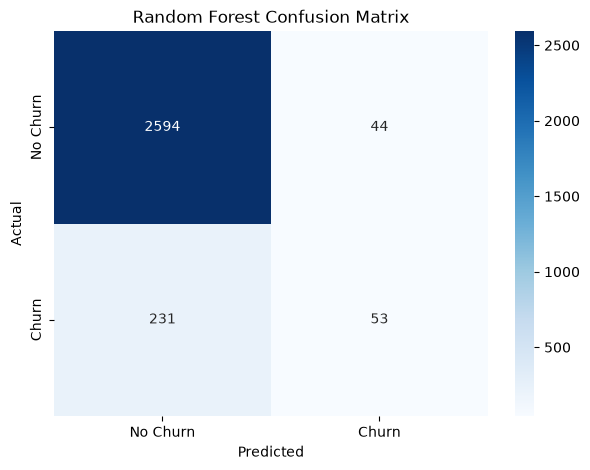

In [22]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [23]:
# Feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 most important features:")
display(feature_importance.head(15))

Top 15 most important features:


,Feature,Importance
0,cons_12m,0.054806
12,margin_net_pow_ele,0.053792
5,forecast_meter_rent_12m,0.052673
11,margin_gross_pow_ele,0.052530
14,net_margin,0.046398
3,forecast_cons_12m,0.046117
2,cons_last_month,0.040521
15,pow_max,0.034337
49,months_activ,0.032639
51,months_modif_prod,0.031274


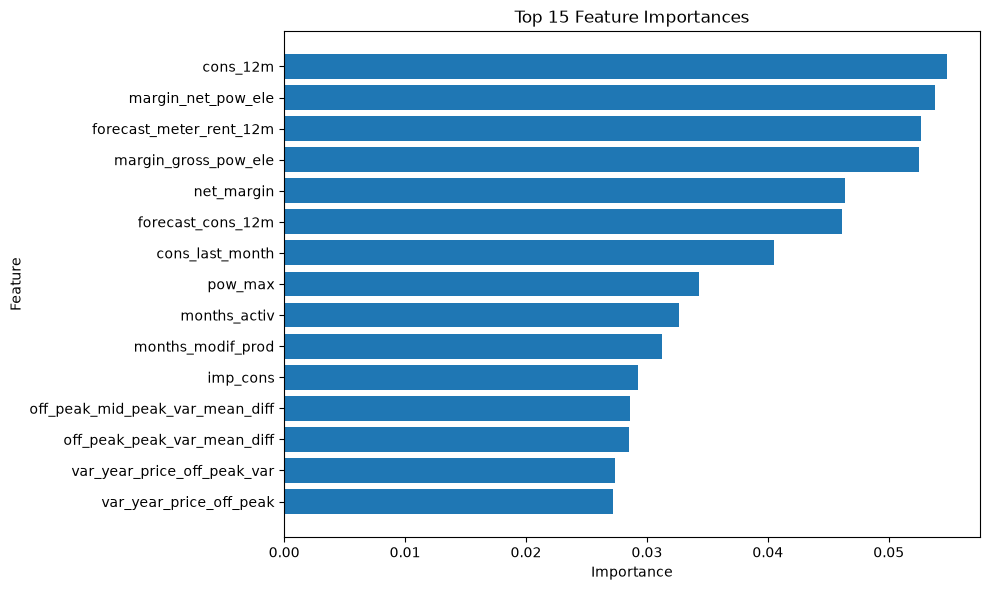

In [24]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

Evaluation Metrics

The dataset is imbalanced, with substantially more customers who did not churn than customers who churned. Therefore, accuracy alone is not sufficient to evaluate the model.

I used precision, recall, F1-score and ROC-AUC, in addition to accuracy.

1. Precision measures how many customers predicted as churners actually churned. This is useful because incorrectly targeting customers who are unlikely to churn could result in unnecessary retention costs.
2. Recall measures how many of the actual churners were successfully identified by the model. This is particularly important because failing to identify a customer who is likely to churn could result in the loss of that customer.
3. F1-score provides a balance between precision and recall and is therefore useful when the classes are imbalanced.
4. ROC-AUC measures the model's ability to distinguish between churn and non-churn customers across different classification thresholds.
5. Accuracy is also reported as an overall measure, but it is not considered the primary metric because of the imbalance in the target variable.
   

Evaluation Metrics:

The dataset is imbalanced, with substantially more customers who did not churn than customers who churned. Therefore, accuracy alone is not sufficient to evaluate the model.

I used precision, recall, F1-score and ROC-AUC, in addition to accuracy.

Precision measures how many customers predicted as churners actually churned. This is useful because incorrectly targeting customers who are unlikely to churn could result in unnecessary retention costs.
Recall measures how many of the actual churners were successfully identified by the model. This is particularly important because failing to identify a customer who is likely to churn could result in the loss of that customer.
F1-score provides a balance between precision and recall and is therefore useful when the classes are imbalanced.
ROC-AUC measures the model's ability to distinguish between churn and non-churn customers across different classification thresholds.
Accuracy is also reported as an overall measure, but it is not considered the primary metric because of the imbalance in the target variable.